In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df['HousePrice'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.shape

(20640, 9)

In [4]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HousePrice,0


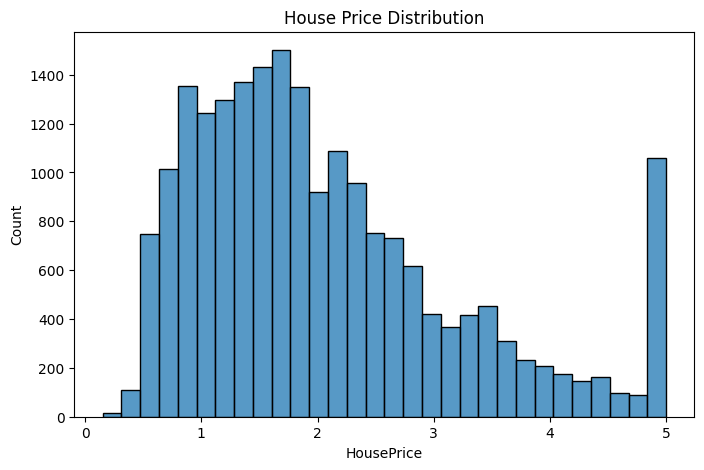

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['HousePrice'], bins=30)

plt.title("House Price Distribution")

plt.show()

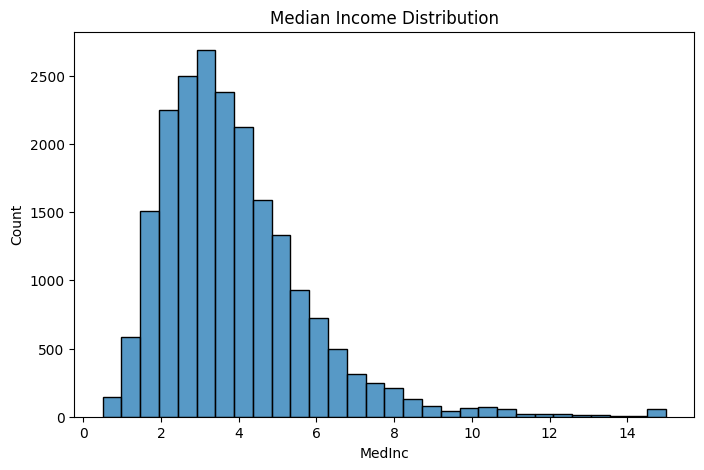

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['MedInc'], bins=30)

plt.title("Median Income Distribution")

plt.show()

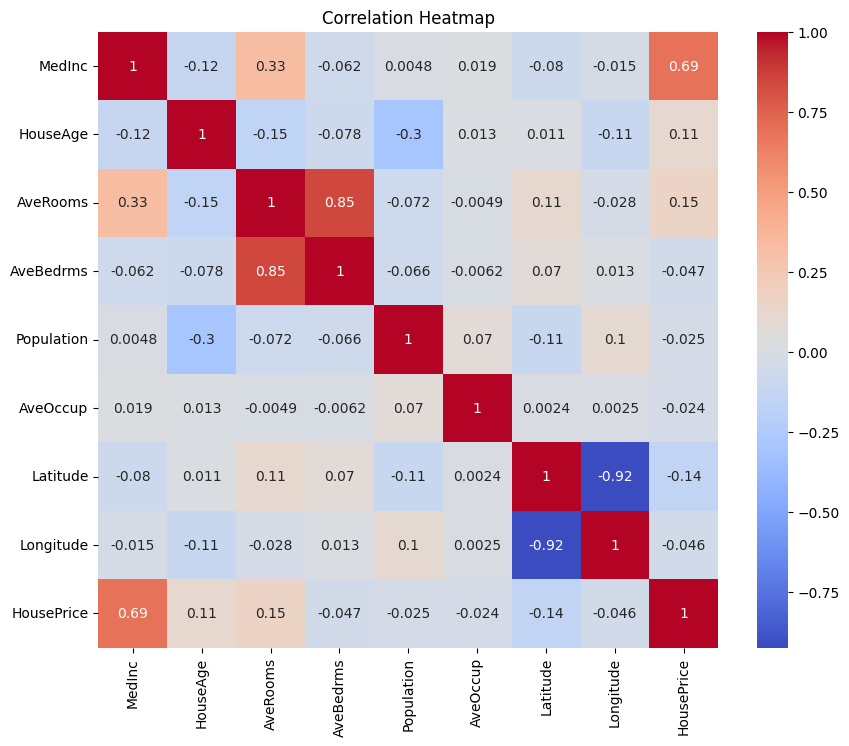

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [11]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
HousePrice,float64


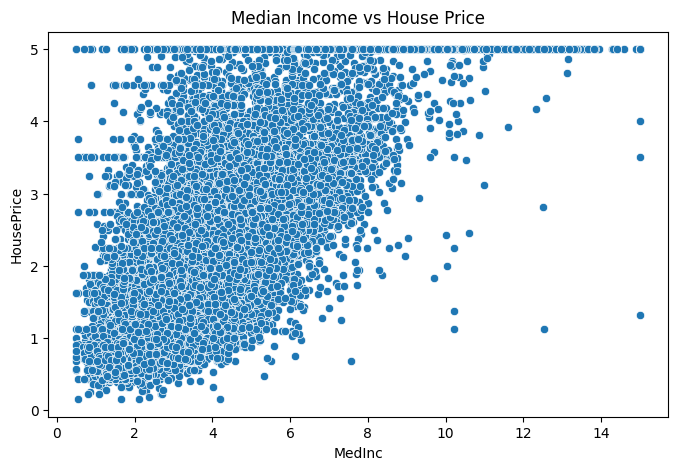

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='MedInc', y='HousePrice', data=df)

plt.title("Median Income vs House Price")

plt.show()

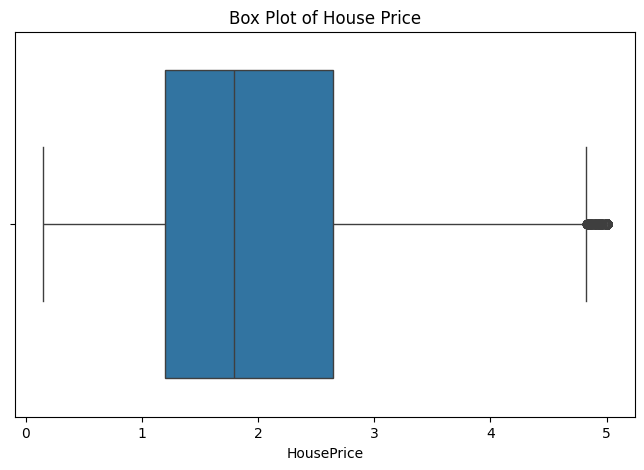

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['HousePrice'])

plt.title("Box Plot of House Price")

plt.show()

In [14]:
X = df.drop('HousePrice', axis=1)

y = df['HousePrice']

print(X.head())

print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HousePrice, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()

In [18]:
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [21]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [22]:
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

In [23]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.5332001304956553


In [24]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.5558915986952444


In [25]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.7455813830127764


In [26]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.5757877060324508


In [27]:
from sklearn.tree import DecisionTreeRegressor

In [28]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [29]:
dt_pred = dt.predict(X_test)

print(dt_pred[:10])

[0.414   1.203   5.00001 2.17    2.257   1.787   2.217   1.74    2.772
 5.00001]


In [30]:
dt_r2 = r2_score(y_test, dt_pred)

print("Linear Regression R2 Score :", r2)

print("Decision Tree R2 Score :", dt_r2)

Linear Regression R2 Score : 0.5757877060324508
Decision Tree R2 Score : 0.622075845135081


In [32]:
print("----------- PROJECT SUMMARY -----------")

print("1. Dataset loaded successfully.")

print("2. EDA completed.")

print("3. No missing values found.")

print("4. Linear Regression model trained.")

print("5. Decision Tree Regressor trained.")

print("6. House prices predicted successfully.")

print("7. Models evaluated using MAE, MSE, RMSE and R2 Score.")

print("Project Completed Successfully!")


----------- PROJECT SUMMARY -----------
1. Dataset loaded successfully.
2. EDA completed.
3. No missing values found.
4. Linear Regression model trained.
5. Decision Tree Regressor trained.
6. House prices predicted successfully.
7. Models evaluated using MAE, MSE, RMSE and R2 Score.
Project Completed Successfully!
